In [19]:
from google.colab import files
files.download("hand_gesture_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9998 - loss: 0.0026
Test Loss: 0.0026
Test Accuracy: 0.9998


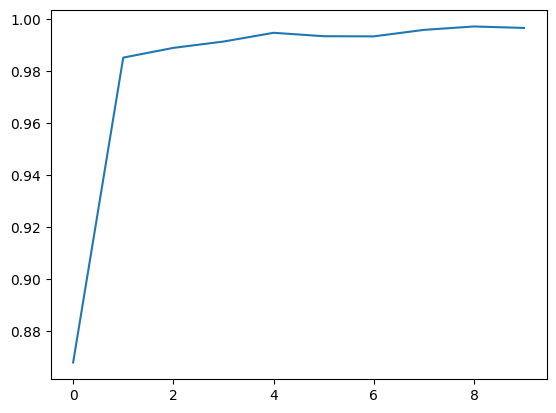

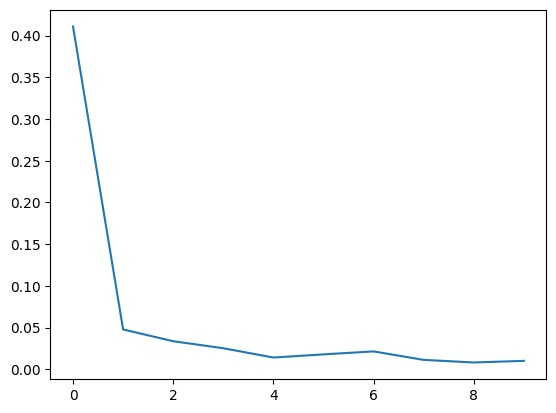

In [17]:
plt.plot(history.history['accuracy'])
...
plt.show()

plt.plot(history.history['loss'])
...
plt.show()

In [16]:
model.save("hand_gesture_model.keras")
print("Model saved successfully!")

Model saved successfully!


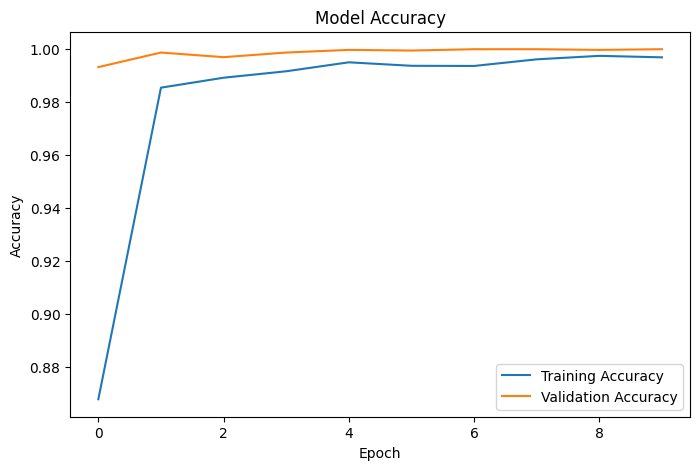

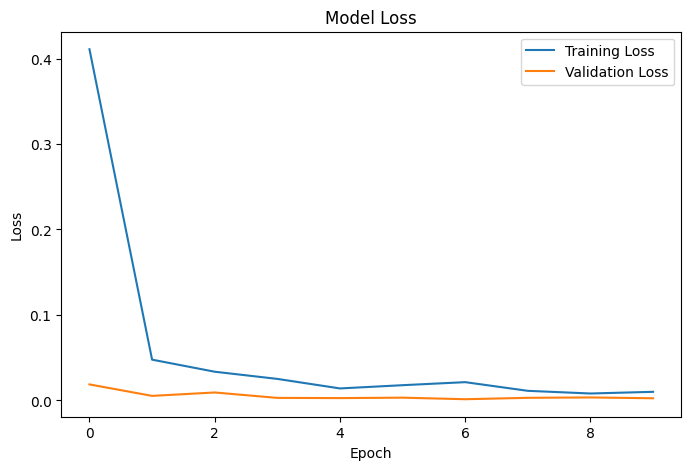

In [15]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [14]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9998 - loss: 0.0026
Test Loss: 0.0025776727125048637
Test Accuracy: 0.999750018119812


In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 107ms/step - accuracy: 0.8677 - loss: 0.4109 - val_accuracy: 0.9930 - val_loss: 0.0188
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 84s 111ms/step - accuracy: 0.9852 - loss: 0.0477 - val_accuracy: 0.9985 - val_loss: 0.0054
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 108ms/step - accuracy: 0.9890 - loss: 0.0336 - val_accuracy: 0.9967 - val_loss: 0.0093
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 104ms/step - accuracy: 0.9914 - loss: 0.0252 - val_accuracy: 0.9985 - val_loss: 0.0030
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 84s 107ms/step - accuracy: 0.9948 - loss: 0.0141 - val_accuracy: 0.9995 - val_loss: 0.0028
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 108ms/step - accuracy: 0.9935 - loss: 0.0179 - val_accuracy: 0.9992 - val_loss: 0.0033
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 103ms/step - accuracy: 0.9934 - loss: 0.0214 - val_accuracy: 0.9998 - val_loss: 0.0014
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 52s 105ms/step - accuracy: 0.9959 - loss: 0

In [12]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,866 (6.20 MB)

 Trainable params: 1,625,866 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Normalize pixel values
X = X / 255.0

# Reshape for CNN
X = X.reshape(-1, 64, 64, 1)

# One-hot encode labels
y = to_categorical(y, num_classes=10)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Images: (16000, 64, 64, 1)
Testing Images: (4000, 64, 64, 1)
Training Labels: (16000, 10)
Testing Labels: (4000, 10)


In [10]:
dataset_path = "/content/hand_gesture_dataset/leapGestRecog"

X = []
y = []

gesture_names = sorted(os.listdir(os.path.join(dataset_path, "00")))
label_map = {gesture: idx for idx, gesture in enumerate(gesture_names)}

print("Label Map:")
print(label_map)

for subject in os.listdir(dataset_path):
    subject_path = os.path.join(dataset_path, subject)

    if os.path.isdir(subject_path):
        for gesture in os.listdir(subject_path):
            gesture_path = os.path.join(subject_path, gesture)

            if os.path.isdir(gesture_path):
                for img_name in os.listdir(gesture_path):
                    img_path = os.path.join(gesture_path, img_name)

                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    img = cv2.resize(img, (64, 64))

                    X.append(img)
                    y.append(label_map[gesture])

X = np.array(X)
y = np.array(y)

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

Label Map:
{'01_palm': 0, '02_l': 1, '03_fist': 2, '04_fist_moved': 3, '05_thumb': 4, '06_index': 5, '07_ok': 6, '08_palm_moved': 7, '09_c': 8, '10_down': 9}
Images Shape: (20000, 64, 64)
Labels Shape: (20000,)


In [9]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

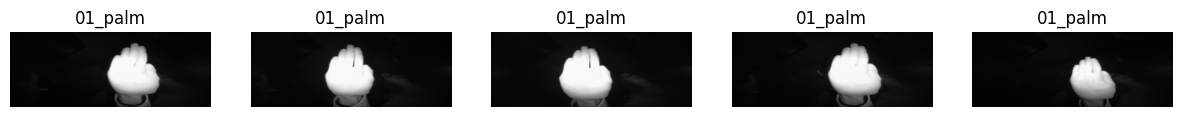

In [8]:
import matplotlib.pyplot as plt
import os
from PIL import Image

dataset_path = "/content/hand_gesture_dataset/leapGestRecog"

subject = "00"
gesture = "01_palm"

gesture_path = os.path.join(dataset_path, subject, gesture)

images = os.listdir(gesture_path)[:5]

plt.figure(figsize=(15,3))

for i, img_name in enumerate(images):
    img = Image.open(os.path.join(gesture_path, img_name))
    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(gesture)
    plt.axis("off")

plt.show()

In [7]:
subject_path = "/content/hand_gesture_dataset/leapGestRecog/00"

print(os.listdir(subject_path))


['08_palm_moved', '04_fist_moved', '03_fist', '02_l', '06_index', '07_ok', '05_thumb', '01_palm', '10_down', '09_c']


In [6]:
import os

dataset_path = "/content/hand_gesture_dataset/leapGestRecog"

print(os.listdir(dataset_path))

['04', '08', '01', '00', '06', '03', '02', '07', '09', '05']


In [5]:
import os

print(os.listdir("/content/hand_gesture_dataset"))

['leapgestrecog', 'leapGestRecog']


In [4]:
import zipfile

zip_path = "/content/leapgestrecog.zip"
extract_path = "/content/hand_gesture_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
!kaggle datasets download -d gti-upm/leapgestrecog

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [01:48<00:00, 21.1MB/s]



In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vanaparthinidhi","key":"15db6981ed73756174b9ce5880a01465"}'}